In [52]:
import numpy as np 
from collections import Counter
from math import log2
import matplotlib.pyplot as plt 
import random 
from statistics import pstdev, mean

In [53]:
'''
returns normalized shannon entropy score over hex numbers
'''
def shannon_hex(hid):
    c = Counter(hid)
    score = (- sum([(val / 16) * log2(val / 16) for _ , val in c.items()]))/4
    return score

In [54]:
'''
64 binary bits, each can take on the value of 0 or 1
'''
def shannon_bin(hid):
    binary = bin(int(hid, 16))[2:].zfill(64)
    c = Counter(binary)
    print(c)
    score = - sum([(val / 64) * log2(val / 64) for _, val in c.items()])
    return score

In [55]:
def plot():
    hex_digs = "0123456789abcdef"
    x = range(len(hex_digs))
    addrs = []
    hex_scores = []
    bin_scores = []

    for i in range(0, 16):
        digs = hex_digs[:i+1]
        addr = digs.zfill(16)
        addrs.append(addr)
        hex_scores.append(shannon_hex(addr))
        bin_scores.append(shannon_bin(addr))
        if i == 5:
            print(f"Entropy score for {addr} is {hex_scores[-1]}")
    plt.plot(x, hex_scores, label="normalized hex scores")
    plt.plot(x, bin_scores, label="bin scores")
    plt.xlabel("Number of unique digits in the address")
    plt.ylabel("Shannon Entropy Score")
    plt.title("Entropy score")
    plt.legend()
    plt.show()

Counter({'0': 64})
Counter({'0': 63, '1': 1})
Counter({'0': 62, '1': 2})
Counter({'0': 60, '1': 4})
Counter({'0': 59, '1': 5})
Counter({'0': 57, '1': 7})
Entropy score for 0000000000012345 is 0.40541019054671457
Counter({'0': 55, '1': 9})
Counter({'0': 52, '1': 12})
Counter({'0': 51, '1': 13})
Counter({'0': 49, '1': 15})
Counter({'0': 47, '1': 17})
Counter({'0': 44, '1': 20})
Counter({'0': 42, '1': 22})
Counter({'0': 39, '1': 25})
Counter({'0': 36, '1': 28})
Counter({'0': 32, '1': 32})


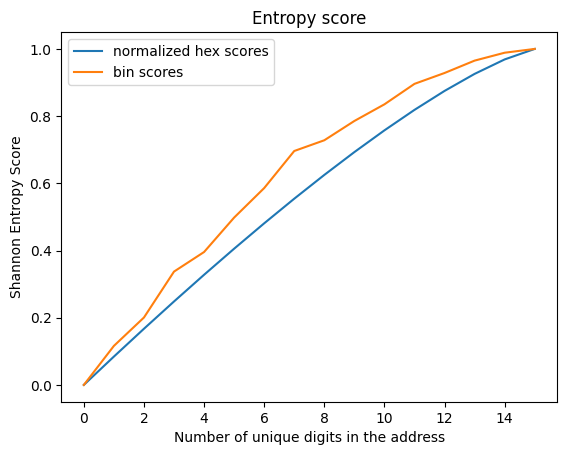

             address                   binary              hexadecimal
Counter({'0': 63, '1': 1})
    0000000000000001      0.11611507530476972      0.08432251665425347
Counter({'0': 59, '1': 5})
    0000000000001234       0.3955378064564774      0.32781953111478324
Counter({'0': 56, '1': 8})
    0101010101010101       0.5435644431995964                     0.25
Counter({'0': 32, '1': 32})
    0f0f0f0f0f0f0f0f                      1.0                     0.25
Counter({'0': 56, '1': 8})
    0000000011111111       0.5435644431995964                     0.25
Counter({'0': 56, '1': 8})
    00000000000021f5       0.5435644431995964      0.32781953111478324
Counter({'0': 43, '1': 21})
    0193025300770135       0.9129992135852473       0.6505542503656206
Counter({'1': 39, '0': 25})
    cec7cb3dce4f938f       0.9652016987500656                  0.78125
Counter({'1': 35, '0': 29})
    f9198bc53b127e76       0.9936507116910404                    0.875
Counter({'1': 35, '0': 29})
    11235677899

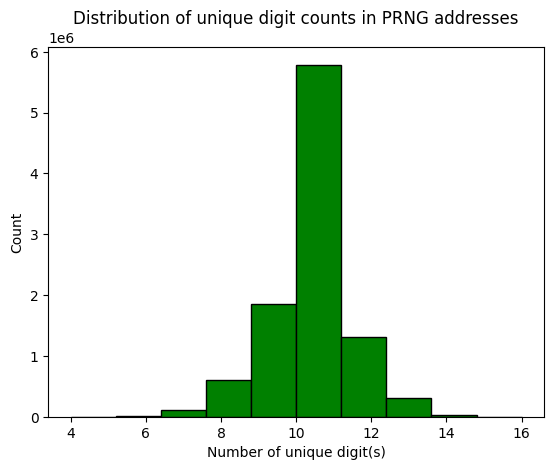

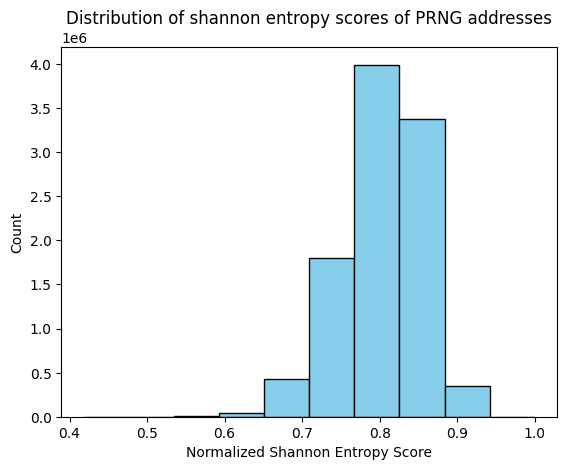

The percentage of addresses that does not contain any alphabet is 0.0005305
The mean of trial data is 0.500015234375
The population standard deviation of trial data is 0.062487489078625315


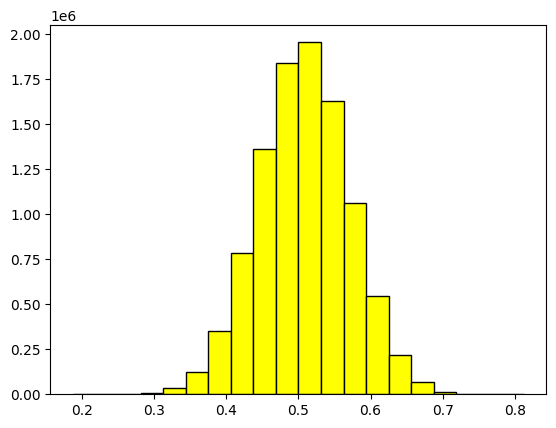

In [56]:
def main():

    hex_host_ids = [
        "0000000000000001", # least random looking
        "0000000000001234", # least random looking
        "0101010101010101", # location
        "0f0f0f0f0f0f0f0f", # location
        ''.join(sorted(list("0101010101010101"))), # same as above but sorted
        "00000000000021f5", # irl example
        "0193025300770135", # irl example of extended v4 address
        "cec7cb3dce4f938f", # made by PRNG
        "f9198bc53b127e76", # made by PRNG
        ''.join(sorted(list("f9198bc53b127e76"))), # same as above but sorted
        "0123456789abcdef", # manual string hitting all hex numbers
        "0468ac7db32e9f15", # same as above but in different order
    ]
    plot()
    print(f"{"address":>20}{"binary":>25}{"hexadecimal":>25}")
    for hid in hex_host_ids:
        print(f"{hid:>20}{shannon_bin(hid):>25}{shannon_hex(hid):>25}")
    
    ntrial = 10000000 # 10 million trials
    hex_digs = list("0123456789abcdef")
    y = []
    entropy_scores = []
    ratios = []
    allnum = 0
    
    for _ in range(ntrial):
        addr = ''.join(random.choices(hex_digs, k=16))
        n_unique_digs = len(set(addr))
        y.append(n_unique_digs)
        entropy_scores.append(shannon_hex(addr))
        ratios.append(get_ratio(addr))
        
        if addr.isdigit():
            allnum += 1

    print(f"Lowest number of unique digits in one address: {min(y)}")
    print(f"Lowest entropy score across all addresses {min(entropy_scores)}")

    plt.hist(y, color='green', edgecolor='black')
    plt.xlabel("Number of unique digit(s)")
    plt.ylabel("Count")
    plt.title("Distribution of unique digit counts in PRNG addresses")
    plt.show()

    plt.hist(entropy_scores, color='skyblue', edgecolor='black')
    plt.xlabel("Normalized Shannon Entropy Score")
    plt.ylabel("Count")
    plt.title("Distribution of shannon entropy scores of PRNG addresses")
    plt.show()

    plt.hist(ratios, bins=20, color='yellow', edgecolor='black')

    print(f"The percentage of addresses that does not contain any alphabet is {allnum/ntrial}")
    print(f"The mean of trial data is {mean(ratios)}")
    print(f"The population standard deviation of trial data is {pstdev(ratios)}")

if __name__ == "__main__":
    main()

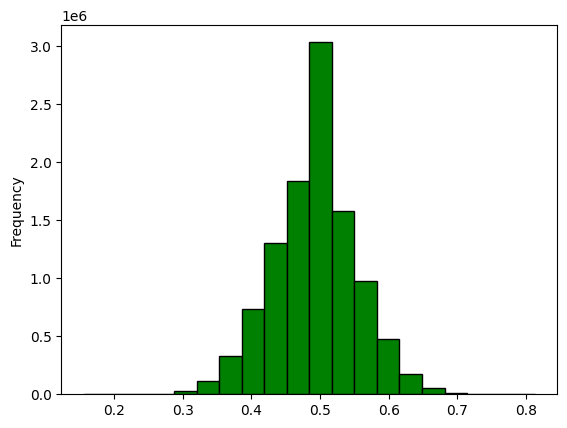

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

def get_ratio(hid):
    binary = bin(int(hid, 16))[2:].zfill(64)
    ratio = binary.count('1') / 64
    return ratio

def plot_dup_data():
    df = pd.read_csv(
        "/home/lyspfan/gatewayscan/data/list.csv",
        header=0,
        usecols=[0],
    )

    ratios = df["hostid"].map(get_ratio)
    ratios.plot(kind="hist", bins=20, color="green", edgecolor="black")
    plt.show()

plot_dup_data()